# Probabilistic-circuit solver — toy problems

Self-contained validation of `calibrated_response.pc`, the generic JAX
probabilistic-circuit solver (see `pc/spec.md`). The solver takes **loss
functions defined over the circuit's marginals/moments** and trains a smooth,
decomposable tensorized SPN by gradient descent. It depends only on
jax/optax/numpy — **nothing else in this notebook is imported from the repo.**

Each problem below re-states its constraints in the solver's own query API,
trains, and checks the recovered distribution against its analytic answer
(exact queries) plus ancestral samples (for correlations).


In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import numpy as np
import jax
import matplotlib.pyplot as plt

from calibrated_response.pc import Circuit, VarSpec, train, TrainConfig, losses, sampling

np.set_printoptions(precision=3, suppress=True)


In [2]:
def solve(specs, terms, *, C=8, K=4, R=8, steps=800, lr=0.03,
          w_dir=0.05, w_iso=0.0, w_ent=0.0, w_cov=0.0, seed=0):
    """Build a circuit and minimise sum(terms) + regularizers.

    `terms` is a list of callables (ckt, params) -> scalar loss, written on top
    of the circuit's query functions (expectation / prob / cond_prob).

    Regularizer knobs:
      w_dir : Dirichlet weight prior (push sum weights toward uniform).
      w_iso : projection isotropy (guard against collapse).
      w_ent : average leaf entropy -- the recommended "be reasonable" prior. A
              tractable, factorization-preserving surrogate for max-entropy: it
              widens per-leaf distributions, so it raises entropy WITHOUT inducing
              cross-variable correlation. Use a modest value (~0.1-1.0).
      w_cov : uniform coverage cross-entropy. Aggressively spreads each *marginal*
              toward uniform and so fills threshold troughs strongly -- but it is
              a marginal-shape target, BLIND to correlation, and can make an
              otherwise-factorized joint dependent (lowering joint entropy). Use
              with care; prefer w_ent.
    """
    ckt = Circuit(specs, C=C, K=K, R=R, seed=seed)
    p0 = ckt.init_params(seed=seed + 1)
    key = jax.random.PRNGKey(seed)

    def loss_fn(p):
        loss = sum(t(ckt, p) for t in terms)
        if w_dir:
            loss = loss + w_dir * losses.dirichlet_regularizer(ckt, p)
        if w_iso:
            loss = loss + w_iso * losses.isotropy_regularizer(ckt, p, key)
        if w_ent:
            loss = loss + w_ent * losses.leaf_entropy_regularizer(ckt, p)
        if w_cov:
            loss = loss + w_cov * losses.uniform_coverage_regularizer(ckt, p, jax.random.fold_in(key, 1))
        return loss

    trained, hist = train(loss_fn, p0, TrainConfig(steps=steps, lr=lr))
    return ckt, trained, hist


def report(rows):
    """rows: list of (name, value, expected, tol_or_None, passed)."""
    ok = True
    print(f"{'check':36s} {'value':>10s} {'expected':>12s}  result")
    print("-" * 74)
    for name, val, exp, tol, passed in rows:
        ok = ok and passed
        v = "  None" if val is None else f"{val:10.3f}"
        e = f"{exp:>12}" if isinstance(exp, str) else f"{exp:12.3f}"
        print(f"{name:36s} {v} {e}  {'PASS' if passed else 'FAIL'}")
    print("-" * 74)
    print("ALL PASS" if ok else "SOME FAILED")
    return ok


def plot_pairwise(ckt, params, n_grid=60, title=None):
    """Exact pairwise marginals straight from the marginal interface: lower
    triangle = 2D heatmaps p(x_j, x_i), diagonal = 1D marginals p(x_i)."""
    specs = ckt.var_specs
    names = [v.name for v in specs]
    n = len(specs)
    G = [np.linspace(v.lower, v.upper, n_grid) if v.kind == "gaussian"
         else np.asarray(v.values, float) for v in specs]

    fig, axes = plt.subplots(n, n, figsize=(2.6 * n, 2.6 * n), squeeze=False)
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if i == j:
                xs = G[i]
                p = np.asarray(ckt.marginal_prob(params, xs, subset=[names[i]]))
                if specs[i].kind == "gaussian":
                    ax.fill_between(xs, p, alpha=0.5, color="steelblue")
                    ax.axvline(float(ckt.expectation(params, names[i])), color="red", ls="--", lw=1.2)
                else:
                    ax.bar(xs, p, width=0.5, color="steelblue", alpha=0.8)
                ax.set_yticks([])
            elif i > j:
                gx, gy = G[j], G[i]
                XX, YY = np.meshgrid(gx, gy)
                pts = np.stack([XX.ravel(), YY.ravel()], axis=1)
                Z = np.asarray(ckt.marginal_prob(params, pts, subset=[names[j], names[i]]))
                ax.pcolormesh(gx, gy, Z.reshape(XX.shape), cmap="Blues", shading="gouraud")
            else:
                ax.axis("off")
            if i == n - 1:
                ax.set_xlabel(names[j])
            if (j == 0 and i > 0) or (i == j == 0):
                ax.set_ylabel(names[i])
    if title:
        fig.suptitle(title, fontweight="bold")
    fig.tight_layout()
    plt.show()


## §8 structural validation

Quick checks on a small mixed instance: normalization (`logZ = 0`), the
moment-pass mass equals 1, exact moments agree with ancestral samples, and
autodiff agrees with finite differences.


In [3]:
ckt = Circuit([VarSpec("X", "gaussian", 0., 100.),
               VarSpec("Z", "categorical", values=(0., 1.)),
               VarSpec("W", "gaussian", 0., 100.)], C=6, K=4, R=4, seed=1)
p = ckt.init_params(seed=2)

logZ = float(ckt.log_marginal(p, np.zeros(3), observed=[False, False, False]))
mass = float(ckt.prob(p, {}))
print(f"normalization  logZ = {logZ:.2e}   (target 0)")
print(f"moment mass    P(true) = {mass:.6f}   (target 1)")

S = sampling.sample(ckt, p, 30000, seed=0)
mx, vx = ckt.linear_moment(p, "X")
print(f"E[X]  query {float(mx):7.3f}  sample {S[:,0].mean():7.3f}")
print(f"P(X>50) query {float(ckt.prob(p, {'X': ('>', 50.)})):.3f}  sample {(S[:,0]>50).mean():.3f}")

def L(pp): return (ckt.expectation(pp, "X") - 30.) ** 2
g = jax.grad(L)(p)["root_W"][0]
e = 1e-3
fd = (L({**p, "root_W": p["root_W"].at[0].add(e)}) - L({**p, "root_W": p["root_W"].at[0].add(-e)})) / (2*e)
print(f"grad check root_W[0]:  autodiff {float(g):.4f}  finite-diff {float(fd):.4f}")
print("\nNote: sample variance of clamped gaussians is slightly below the exact"
      " moment because ancestral samples are clipped to [lower, upper].")


normalization  logZ = 0.00e+00   (target 0)
moment mass    P(true) = 1.000000   (target 1)
E[X]  query  45.854  sample  46.031
P(X>50) query 0.442  sample 0.442
grad check root_W[0]:  autodiff -7.9001  finite-diff -7.8583

Note: sample variance of clamped gaussians is slightly below the exact moment because ancestral samples are clipped to [lower, upper].


## 1. Single mean — `E[X] = 25`

MaxEnt on `[0,100]` with only a mean constraint tilts mass downward; the
recovered mean must equal 25 and sit below the midpoint.


check                                     value     expected  result
--------------------------------------------------------------------------
E[X]                                     25.026       25.000  PASS
E[X] < 50 (skew)                         25.026         < 50  PASS
sample mean                              28.101       25.000  PASS
--------------------------------------------------------------------------
ALL PASS


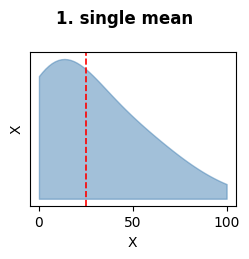

In [4]:
specs = [VarSpec("X", "gaussian", 0., 100.)]
terms = [lambda c, p: losses.match_expectation(c, p, "X", 25.0)]
ckt, tp, _ = solve(specs, terms, C=6, K=4, R=4, steps=600, lr=0.05, seed=0)

ex = float(ckt.expectation(tp, "X"))
S = sampling.sample(ckt, tp, 20000, seed=1)
report([
    ("E[X]",            ex,            25.0, 4.0, abs(ex - 25.0) < 4.0),
    ("E[X] < 50 (skew)", ex,           "< 50", None, ex < 50.0),
    ("sample mean",     S[:,0].mean(), 25.0, 5.0, abs(S[:,0].mean() - 25.0) < 5.0),
])
plot_pairwise(ckt, tp, title="1. single mean")


## 2. Independent marginals — `E[X]=25`, `E[Y]=75`, no joint info

With only marginal constraints the MaxEnt joint factorises, so `Corr(X,Y) ≈ 0`.


check                                     value     expected  result
--------------------------------------------------------------------------
E[X]                                     25.024       25.000  PASS
E[Y]                                     74.970       75.000  PASS
Corr(X,Y)                                -0.132        0.000  PASS
--------------------------------------------------------------------------
ALL PASS


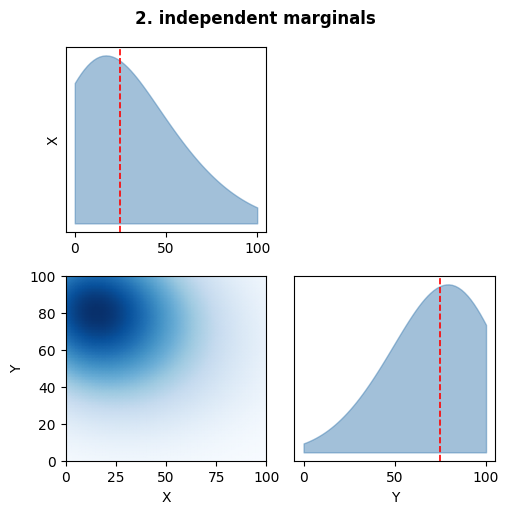

In [5]:
specs = [VarSpec("X", "gaussian", 0., 100.), VarSpec("Y", "gaussian", 0., 100.)]
terms = [lambda c, p: losses.match_expectation(c, p, "X", 25.0),
         lambda c, p: losses.match_expectation(c, p, "Y", 75.0)]
ckt, tp, _ = solve(specs, terms, C=8, K=4, R=6, steps=700, lr=0.04, seed=0)

ex = float(ckt.expectation(tp, "X")); ey = float(ckt.expectation(tp, "Y"))
S = sampling.sample(ckt, tp, 30000, seed=1)
corr = float(np.corrcoef(S[:,0], S[:,1])[0,1])
report([
    ("E[X]",      ex,   25.0, 4.0,  abs(ex-25.0) < 4.0),
    ("E[Y]",      ey,   75.0, 4.0,  abs(ey-75.0) < 4.0),
    ("Corr(X,Y)", corr,  0.0, 0.15, abs(corr) < 0.15),
])
plot_pairwise(ckt, tp, title="2. independent marginals")


## 3. Conditional expectation — law of total expectation

`P(Z=T)=0.30`, `E[X|Z=T]=80`, `E[X|Z=F]=20`  ⇒  `E[X] = 0.3·80 + 0.7·20 = 38`.
Requires X and Z to be **dependent**, which the mixture-over-repetitions
captures even though each repetition factorises.


check                                     value     expected  result
--------------------------------------------------------------------------
P(Z=T)                                    0.307        0.300  PASS
E[X|Z=T]                                 80.004       80.000  PASS
E[X|Z=F]                                 20.025       20.000  PASS
E[X] (LTE=38)                            38.426       38.000  PASS
--------------------------------------------------------------------------
ALL PASS


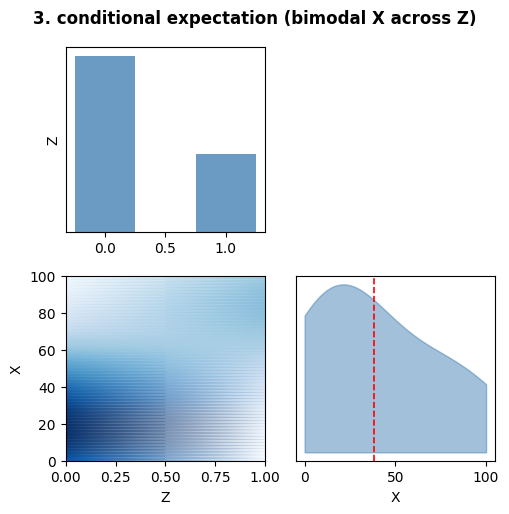

In [10]:
specs = [VarSpec("Z", "categorical", values=(0., 1.)), VarSpec("X", "gaussian", 0., 100.)]
T, F = {"Z": ("=", 1.0)}, {"Z": ("=", 0.0)}
# Probability residuals are O(1e-3); the conditional-mean residuals are O(10).
# Weight the probability term up so the optimizer respects all constraints.
terms = [
    lambda c, p: losses.match_prob(c, p, T, 0.30, weight=80.0),
    lambda c, p: 0.02 * (c.expectation(p, "X", event=T) - 80.0) ** 2,
    lambda c, p: 0.02 * (c.expectation(p, "X", event=F) - 20.0) ** 2,
]
ckt, tp, _ = solve(specs, terms, C=10, K=4, R=10, steps=2000, lr=0.03, seed=0)

pT  = float(ckt.prob(tp, T))
exT = float(ckt.expectation(tp, "X", event=T))
exF = float(ckt.expectation(tp, "X", event=F))
ex  = float(ckt.expectation(tp, "X"))
report([
    ("P(Z=T)",       pT,  0.30, 0.05, abs(pT-0.30) < 0.05),
    ("E[X|Z=T]",     exT, 80.0, 8.0,  abs(exT-80.0) < 8.0),
    ("E[X|Z=F]",     exF, 20.0, 8.0,  abs(exF-20.0) < 8.0),
    ("E[X] (LTE=38)", ex, 38.0, 5.0,  abs(ex-38.0) < 5.0),
])
plot_pairwise(ckt, tp, title="3. conditional expectation (bimodal X across Z)")


## 4. Markov chain `A → B → C`

`P(A>50)=0.70`; `P(B>50|A>50)=0.80`, `P(B>50|A<50)=0.10`; same for `C|B`.
Law of total probability ⇒ `P(B>50)=0.59`, `P(C>50)≈0.513`; all pairs positively
correlated.


In [ ]:
specs = [VarSpec(n, "gaussian", 0., 100.) for n in ("A", "B", "C")]
Ah, Al = {"A": (">", 50.)}, {"A": ("<", 50.)}
Bh, Bl = {"B": (">", 50.)}, {"B": ("<", 50.)}
W = 10.0   # probability-scale constraints need weight to compete with regularizers
terms = [
    lambda c, p: losses.match_prob(c, p, Ah, 0.70, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, Bh, Ah, 0.80, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, Bh, Al, 0.10, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 50.)}, Bh, 0.80, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 50.)}, Bl, 0.10, weight=W),
]
ckt, tp, _ = solve(specs, terms, C=4, K=60, R=12, steps=4000, lr=0.035, seed=0, w_ent=0.00)

pA = float(ckt.prob(tp, Ah)); pB = float(ckt.prob(tp, Bh)); pC = float(ckt.prob(tp, {"C": (">", 50.)}))
S = sampling.sample(ckt, tp, 40000, seed=1)
cab = float(np.corrcoef(S[:,0], S[:,1])[0,1]); cbc = float(np.corrcoef(S[:,1], S[:,2])[0,1])
report([
    ("P(A>50)",   pA, 0.700, 0.06, abs(pA-0.70) < 0.06),
    ("P(B>50)",   pB, 0.590, 0.06, abs(pB-0.59) < 0.06),
    ("P(C>50)",   pC, 0.513, 0.06, abs(pC-0.513) < 0.06),
    ("Corr(A,B)>0", cab, "> 0", None, cab > 0.05),
    ("Corr(B,C)>0", cbc, "> 0", None, cbc > 0.05),
])
plot_pairwise(ckt, tp, title="4. Markov chain A->B->C")


## 5. Fork Bayes net `A → B`, `A → C`

Two CPT rows per child. Marginals are analytic; B and C are marginally
correlated (common cause) but less correlated *within* an A-stratum.


In [ ]:
specs = [VarSpec(n, "gaussian", 0., 100.) for n in ("A", "B", "C")]
Ah, Al = {"A": (">", 50.)}, {"A": ("<", 50.)}
W, WA = 10.0, 25.0   # extra weight on the A prior so the common cause is pinned
terms = [
    lambda c, p: losses.match_prob(c, p, Ah, 0.40, weight=WA),
    lambda c, p: losses.match_cond_prob(c, p, {"B": (">", 60.)}, Ah, 0.72, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"B": (">", 60.)}, Al, 0.12, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"B": (">", 25.)}, Ah, 0.95, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"B": (">", 25.)}, Al, 0.45, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 55.)}, Ah, 0.75, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 55.)}, Al, 0.10, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 20.)}, Ah, 0.95, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 20.)}, Al, 0.50, weight=W),
]
ckt, tp, _ = solve(specs, terms, C=12, K=5, R=16, steps=3500, lr=0.02, seed=0)

g = lambda ev: float(ckt.prob(tp, ev))
S = sampling.sample(ckt, tp, 50000, seed=1)
a, b, c_ = S[:,0], S[:,1], S[:,2]
cbc = float(np.corrcoef(b, c_)[0,1])
hi = a > 50; lo = a <= 50
cbc_hi = float(np.corrcoef(b[hi], c_[hi])[0,1]) if hi.sum() > 30 else np.nan
report([
    ("P(A>50)", g(Ah),               0.40, 0.07, abs(g(Ah)-0.40) < 0.07),
    ("P(B>60)", g({"B": (">",60.)}), 0.360, 0.07, abs(g({"B": (">",60.)})-0.360) < 0.07),
    ("P(B>25)", g({"B": (">",25.)}), 0.650, 0.07, abs(g({"B": (">",25.)})-0.650) < 0.07),
    ("P(C>55)", g({"C": (">",55.)}), 0.360, 0.07, abs(g({"C": (">",55.)})-0.360) < 0.07),
    ("P(C>20)", g({"C": (">",20.)}), 0.680, 0.07, abs(g({"C": (">",20.)})-0.680) < 0.07),
    ("Corr(B,C) > 0",        cbc,    "> 0", None, cbc > 0.05),
    ("Corr(B,C|A>50) < Corr(B,C)", cbc_hi, "< Corr", None, (not np.isnan(cbc_hi)) and cbc_hi < cbc),
])
plot_pairwise(ckt, tp, title="5. fork Bayes net (B,C correlated via A)")


## Marginal interface for losses

`circuit.marginal_log_prob(params, points, subset)` evaluates the marginal
`p(x_S)` at a **batch** of points (every variable outside `subset` integrated
out), returning `(B,)` and differentiable in `params`. Build losses directly on
it: NLL/KL to a sample, or matching a target marginal *table* on a grid. The
helpers `losses.marginal_nll` and `losses.match_marginal` wrap the common cases.


In [ ]:
mck = Circuit([VarSpec("X", "gaussian", 0., 100.),
                VarSpec("Z", "categorical", values=(0., 1.)),
                VarSpec("Y", "gaussian", 0., 100.)], C=6, K=4, R=4, seed=1)
mp = mck.init_params(seed=2)

# batched marginal density of X at several points (Y, Z integrated out)
xs = np.linspace(5, 95, 7)
print("p(X) at", xs, "=\n ", np.asarray(mck.marginal_prob(mp, xs, subset=["X"])))

# categorical marginal table sums to 1
print("P(Z=0), P(Z=1) =", np.asarray(mck.marginal_prob(mp, np.array([0., 1.]), subset=["Z"])))

# joint 2-variable marginal p(X, Z) at a batch of points
pts = np.array([[20., 1.], [80., 0.], [50., 1.]])
print("p(X,Z) =", np.asarray(mck.marginal_prob(mp, pts, subset=["X", "Z"])))

# fit the marginal of X to data by NLL (differentiable in params)
data = np.random.default_rng(0).normal(30, 8, size=(2000, 1)).clip(0, 100)
loss = lambda p: losses.marginal_nll(mck, p, data, subset=["X"]) + 0.01 * losses.dirichlet_regularizer(mck, p)
fit, hist = train(loss, mp, TrainConfig(steps=400, lr=0.05))
print(f"NLL {hist[0]:.2f} -> {hist[-1]:.2f}; fitted E[X]={float(mck.expectation(fit,'X')):.2f}"
      f" (data mean {data.mean():.2f})")

# Note: integrating p(X) over [0,100] gives <1 because the gaussian leaves are
# unbounded; the missing mass is the tails outside the box (see open question on
# truncated leaves). The density is proper over all of R.


## Reasonableness knob: entropy vs the threshold trough

Constraints that only pin *threshold masses* (problems 3-5) leave the density
shape free, and the mixture carves a sharp trough at the conditioning threshold
to make the latent "which side" decision crisp. The principled "be reasonable
where the constraints are silent" objective is **maximum entropy** — which the
spec excludes as intractable for a non-deterministic circuit (§6/§10). We use a
tractable surrogate instead:

* **`w_ent` (recommended)** — `losses.leaf_entropy_regularizer`: maximize average
  *leaf* entropy. Because it acts per-leaf it raises entropy **without** inducing
  cross-variable correlation, so it pushes the under-determined part toward the
  factorized max-entropy default. Gentle: it softens the trough rather than
  erasing it.
* **`w_cov` (use with care)** — `losses.uniform_coverage_regularizer`: a
  marginal-*shape* target that fills troughs aggressively, but is blind to
  correlation and can make an otherwise-independent joint dependent (lowering
  joint entropy).

The cell below shows both points: (1) on the *independent* problem `w_cov`
fabricates correlation while `w_ent` keeps `Corr(X,Y)≈0`; (2) on the chain,
`w_ent` gently fills the trough.


In [ ]:
# (1) factorability: w_ent preserves independence; w_cov does not
ind_specs = [VarSpec("X", "gaussian", 0., 100.), VarSpec("Y", "gaussian", 0., 100.)]
ind_terms = [lambda c, p: losses.match_expectation(c, p, "X", 25.0),
             lambda c, p: losses.match_expectation(c, p, "Y", 75.0)]
print("independent problem (want Corr(X,Y) ~ 0):")
for label, kw in [("baseline", {}), ("w_cov=0.15", dict(w_cov=0.15)), ("w_ent=0.3", dict(w_ent=0.3))]:
    ckt, tp, _ = solve(ind_specs, ind_terms, C=10, K=4, R=12, steps=1200, lr=0.04, seed=0, **kw)
    S = sampling.sample(ckt, tp, 30000, seed=2)
    print(f"  {label:11s} Corr(X,Y) = {np.corrcoef(S[:,0], S[:,1])[0,1]:+.3f}")

# (2) chain: w_ent gently fills the threshold trough
chain_specs = [VarSpec(n, "gaussian", 0., 100.) for n in ("A", "B", "C")]
Ah, Al = {"A": (">", 50.)}, {"A": ("<", 50.)}
Bh, Bl = {"B": (">", 50.)}, {"B": ("<", 50.)}
chain_terms = [
    lambda c, p: losses.match_prob(c, p, Ah, 0.70, weight=10.0),
    lambda c, p: losses.match_cond_prob(c, p, Bh, Ah, 0.80, weight=10.0),
    lambda c, p: losses.match_cond_prob(c, p, Bh, Al, 0.10, weight=10.0),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 50.)}, Bh, 0.80, weight=10.0),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 50.)}, Bl, 0.10, weight=10.0),
]
grid = np.linspace(0, 100, 201)
fig, ax = plt.subplots(figsize=(7, 4))
for w_ent, color in [(0.0, "crimson"), (1.0, "steelblue")]:
    ckt, tp, _ = solve(chain_specs, chain_terms, C=10, K=4, R=12, steps=2200, lr=0.03, w_ent=w_ent, seed=0)
    dens = np.asarray(ckt.marginal_prob(tp, grid, subset=["A"]))
    dip = dens[abs(grid - 50) <= 1].mean() / dens.max()
    pa = float(ckt.prob(tp, Ah))
    ax.plot(grid, dens, color=color, lw=2, label=f"w_ent={w_ent}  (P(A>50)={pa:.2f}, density@50/peak={dip:.2f})")
ax.axvline(50, color="gray", ls=":", lw=1)
ax.set_title("Chain p(A): leaf-entropy knob gently fills the trough")
ax.set_xlabel("A"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()
